In [1]:
from argparse import Namespace
from src.dataset import WayMoDataset

args = Namespace(
    fps=2.5,
    hist_step=8,
    pred_step=1,
    roll_step=12,
    skip_step=1,
    dot_per_meter=1,
    cache_dataset=True, 

)
dataset = WayMoDataset.load_data(args, './data/WayMo/Processed/00552_26_c1213bb8de07246e/data.csv.gz')
dataset

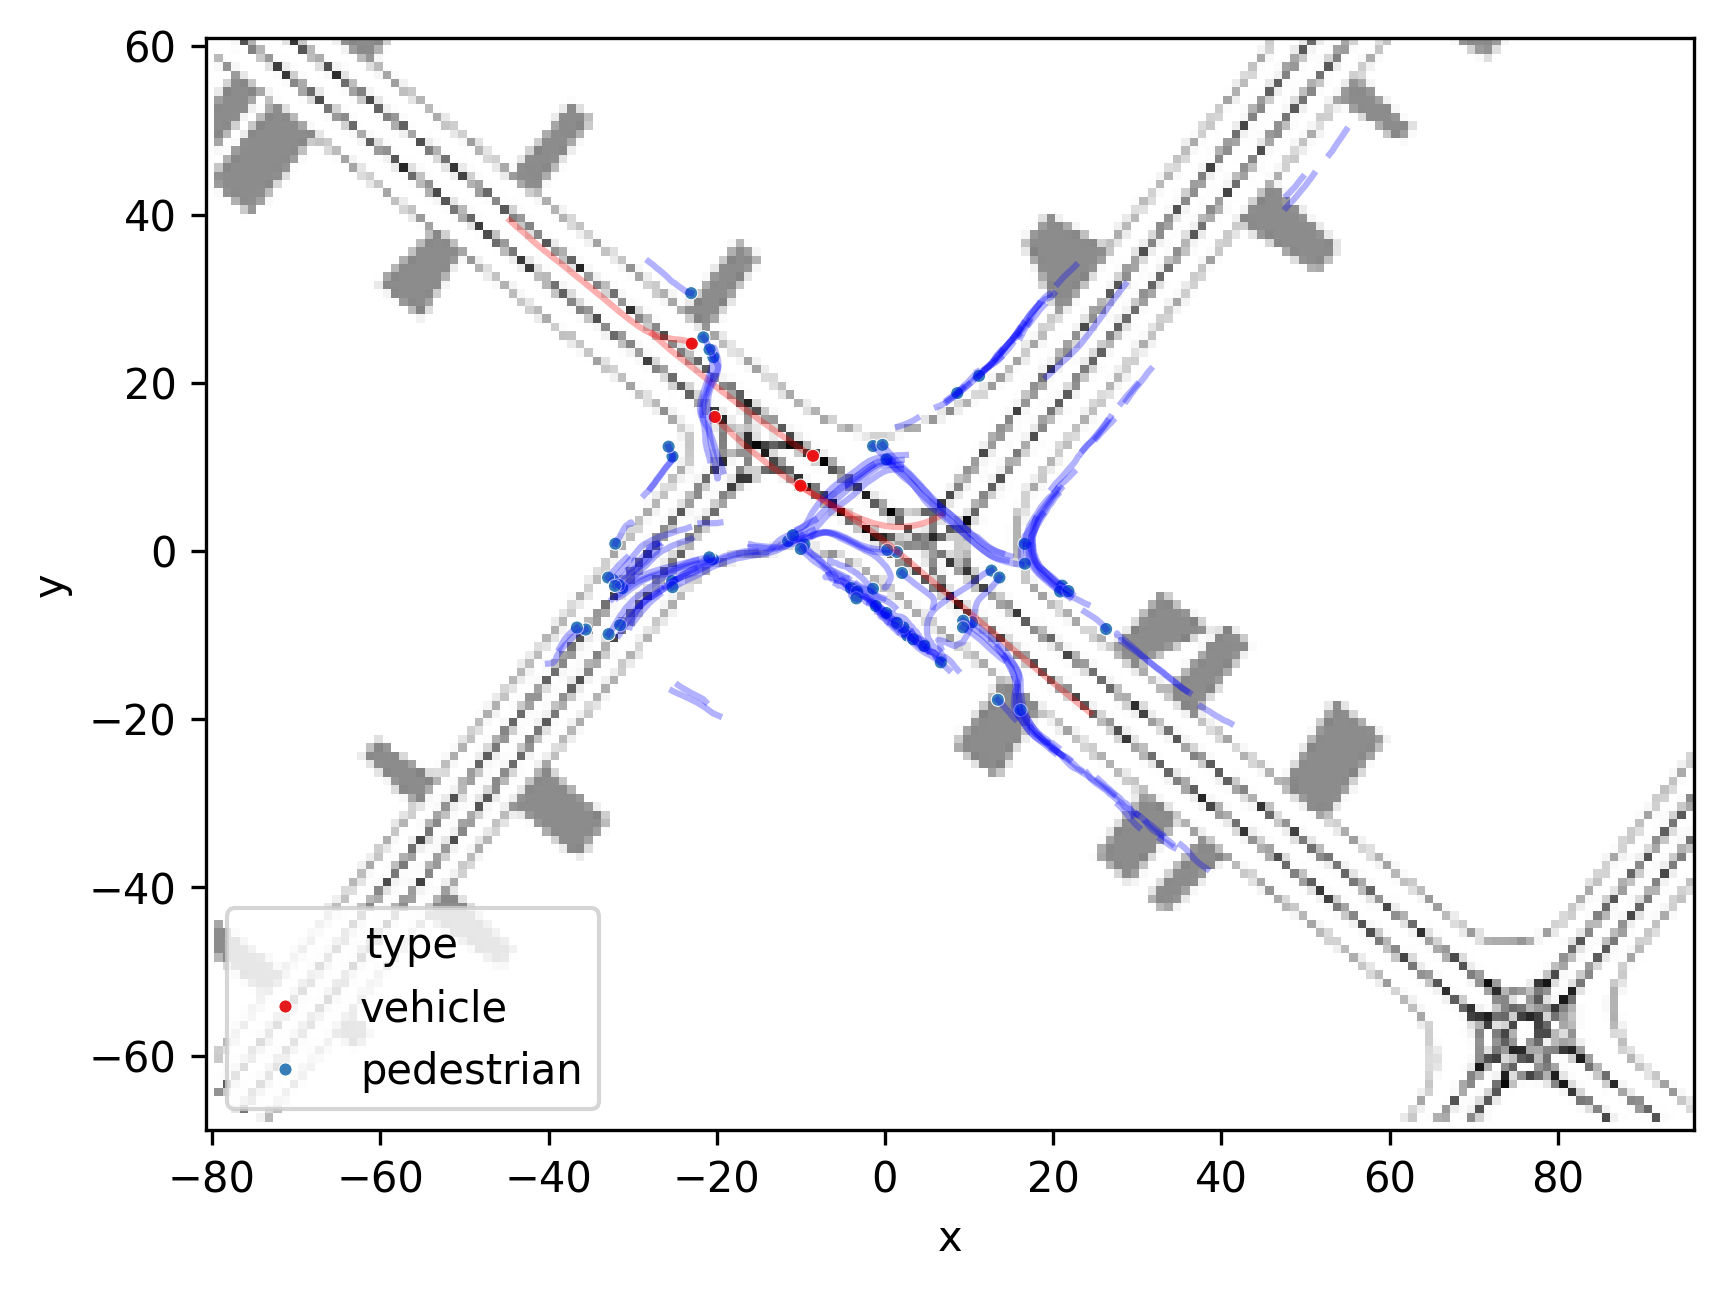

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(dpi=300)

map_data = dataset.map_data
plt.imshow( map_data.map.T, extent=[ map_data.xmin, map_data.xmax, map_data.ymin, map_data.ymax ], origin='lower', cmap='gray_r', interpolation='nearest' )

df_data = dataset.df_data[dataset.df_data["f"] == dataset.df_data["f"].min()]
sns.scatterplot( data=df_data, x="x", y="y", hue="type", palette="Set1", s=10 )
for pid, group in dataset.df_data.groupby("id"):
    color = 'blue' if group["type"].iloc[0] == 'pedestrian' else 'red'
    plt.plot( group["x"], group["y"], alpha=0.3, color=color )

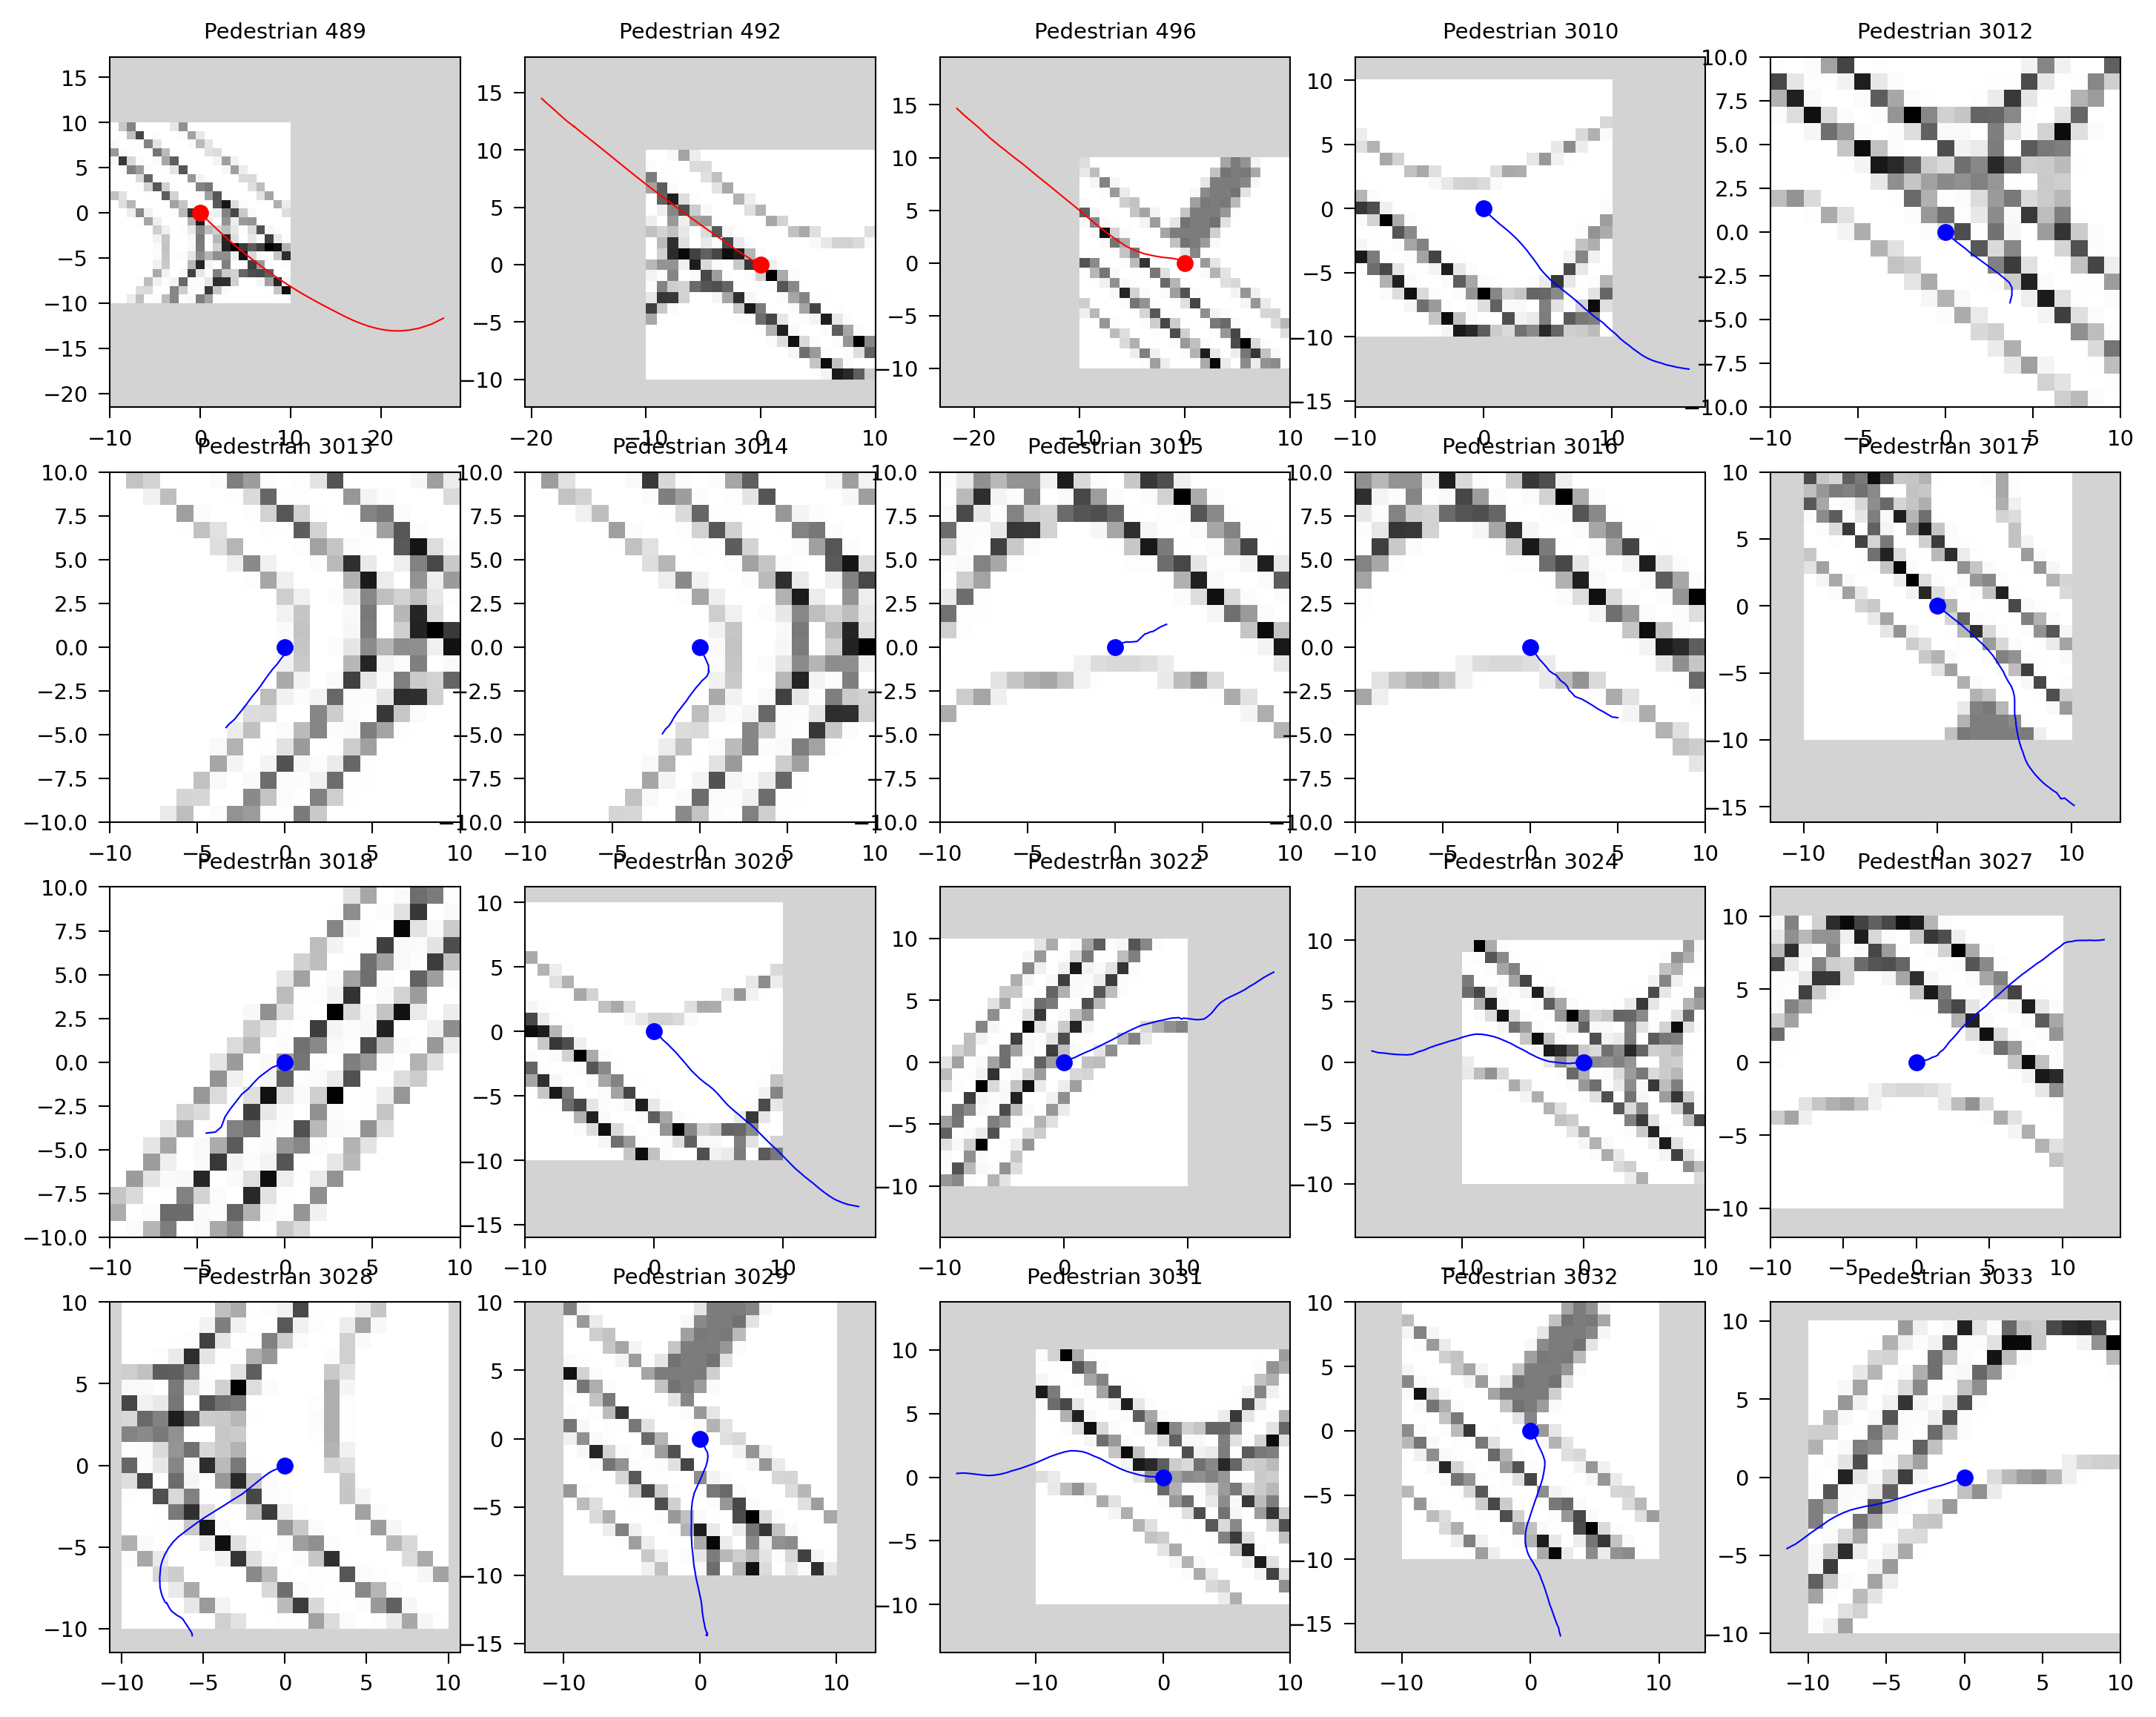

In [ ]:
import numpy as np
from src.utils.plot import get_fig
from src.utils.extract_patches import extract_patches_numpy, extract_patches_torch

pos = df_data[['x', 'y']].values # (N, 2)
idx = np.round((pos[..., 0] - map_data.xmin) / (map_data.xmax-map_data.xmin) * map_data.map.shape[0]).clip(0, map_data.map.shape[0] - 1).astype(int)  # (batch_size, #pedestrian)
jdx = np.round((pos[..., 1] - map_data.ymin) / (map_data.ymax-map_data.ymin) * map_data.map.shape[1]).clip(0, map_data.map.shape[1] - 1).astype(int)  # (batch_size, #pedestrian)
patches = extract_patches_numpy(map_data.map, idx, jdx, r=10)

N = min(patches.shape[0], 20)
C = 5
R = np.ceil(N / C).astype(int)
fi, fig, axes = get_fig(R, C, AW=4, AH=4)

for i in range(N):
    ax = axes[i]
    ax.set_facecolor('lightgray')
    im = ax.imshow(patches[i].T, extent=[-10,10,-10,10], origin='lower', cmap='gray_r', interpolation='nearest', aspect='auto')
    ax.set_title(f'Pedestrian {df_data["id"].iloc[i]}')
    traj = dataset.df_data[dataset.df_data["id"]==df_data["id"].iloc[i]]
    color = 'blue' if traj["type"].iloc[0] == 'pedestrian' else 'red'
    ax.scatter(0, 0, c=color, s=20, label='Current Position')
    ax.plot(traj["x"] - df_data['x'].iloc[i], traj["y"] - df_data['y'].iloc[i], c=color, label='Trajectory')
    ax.axis('equal')

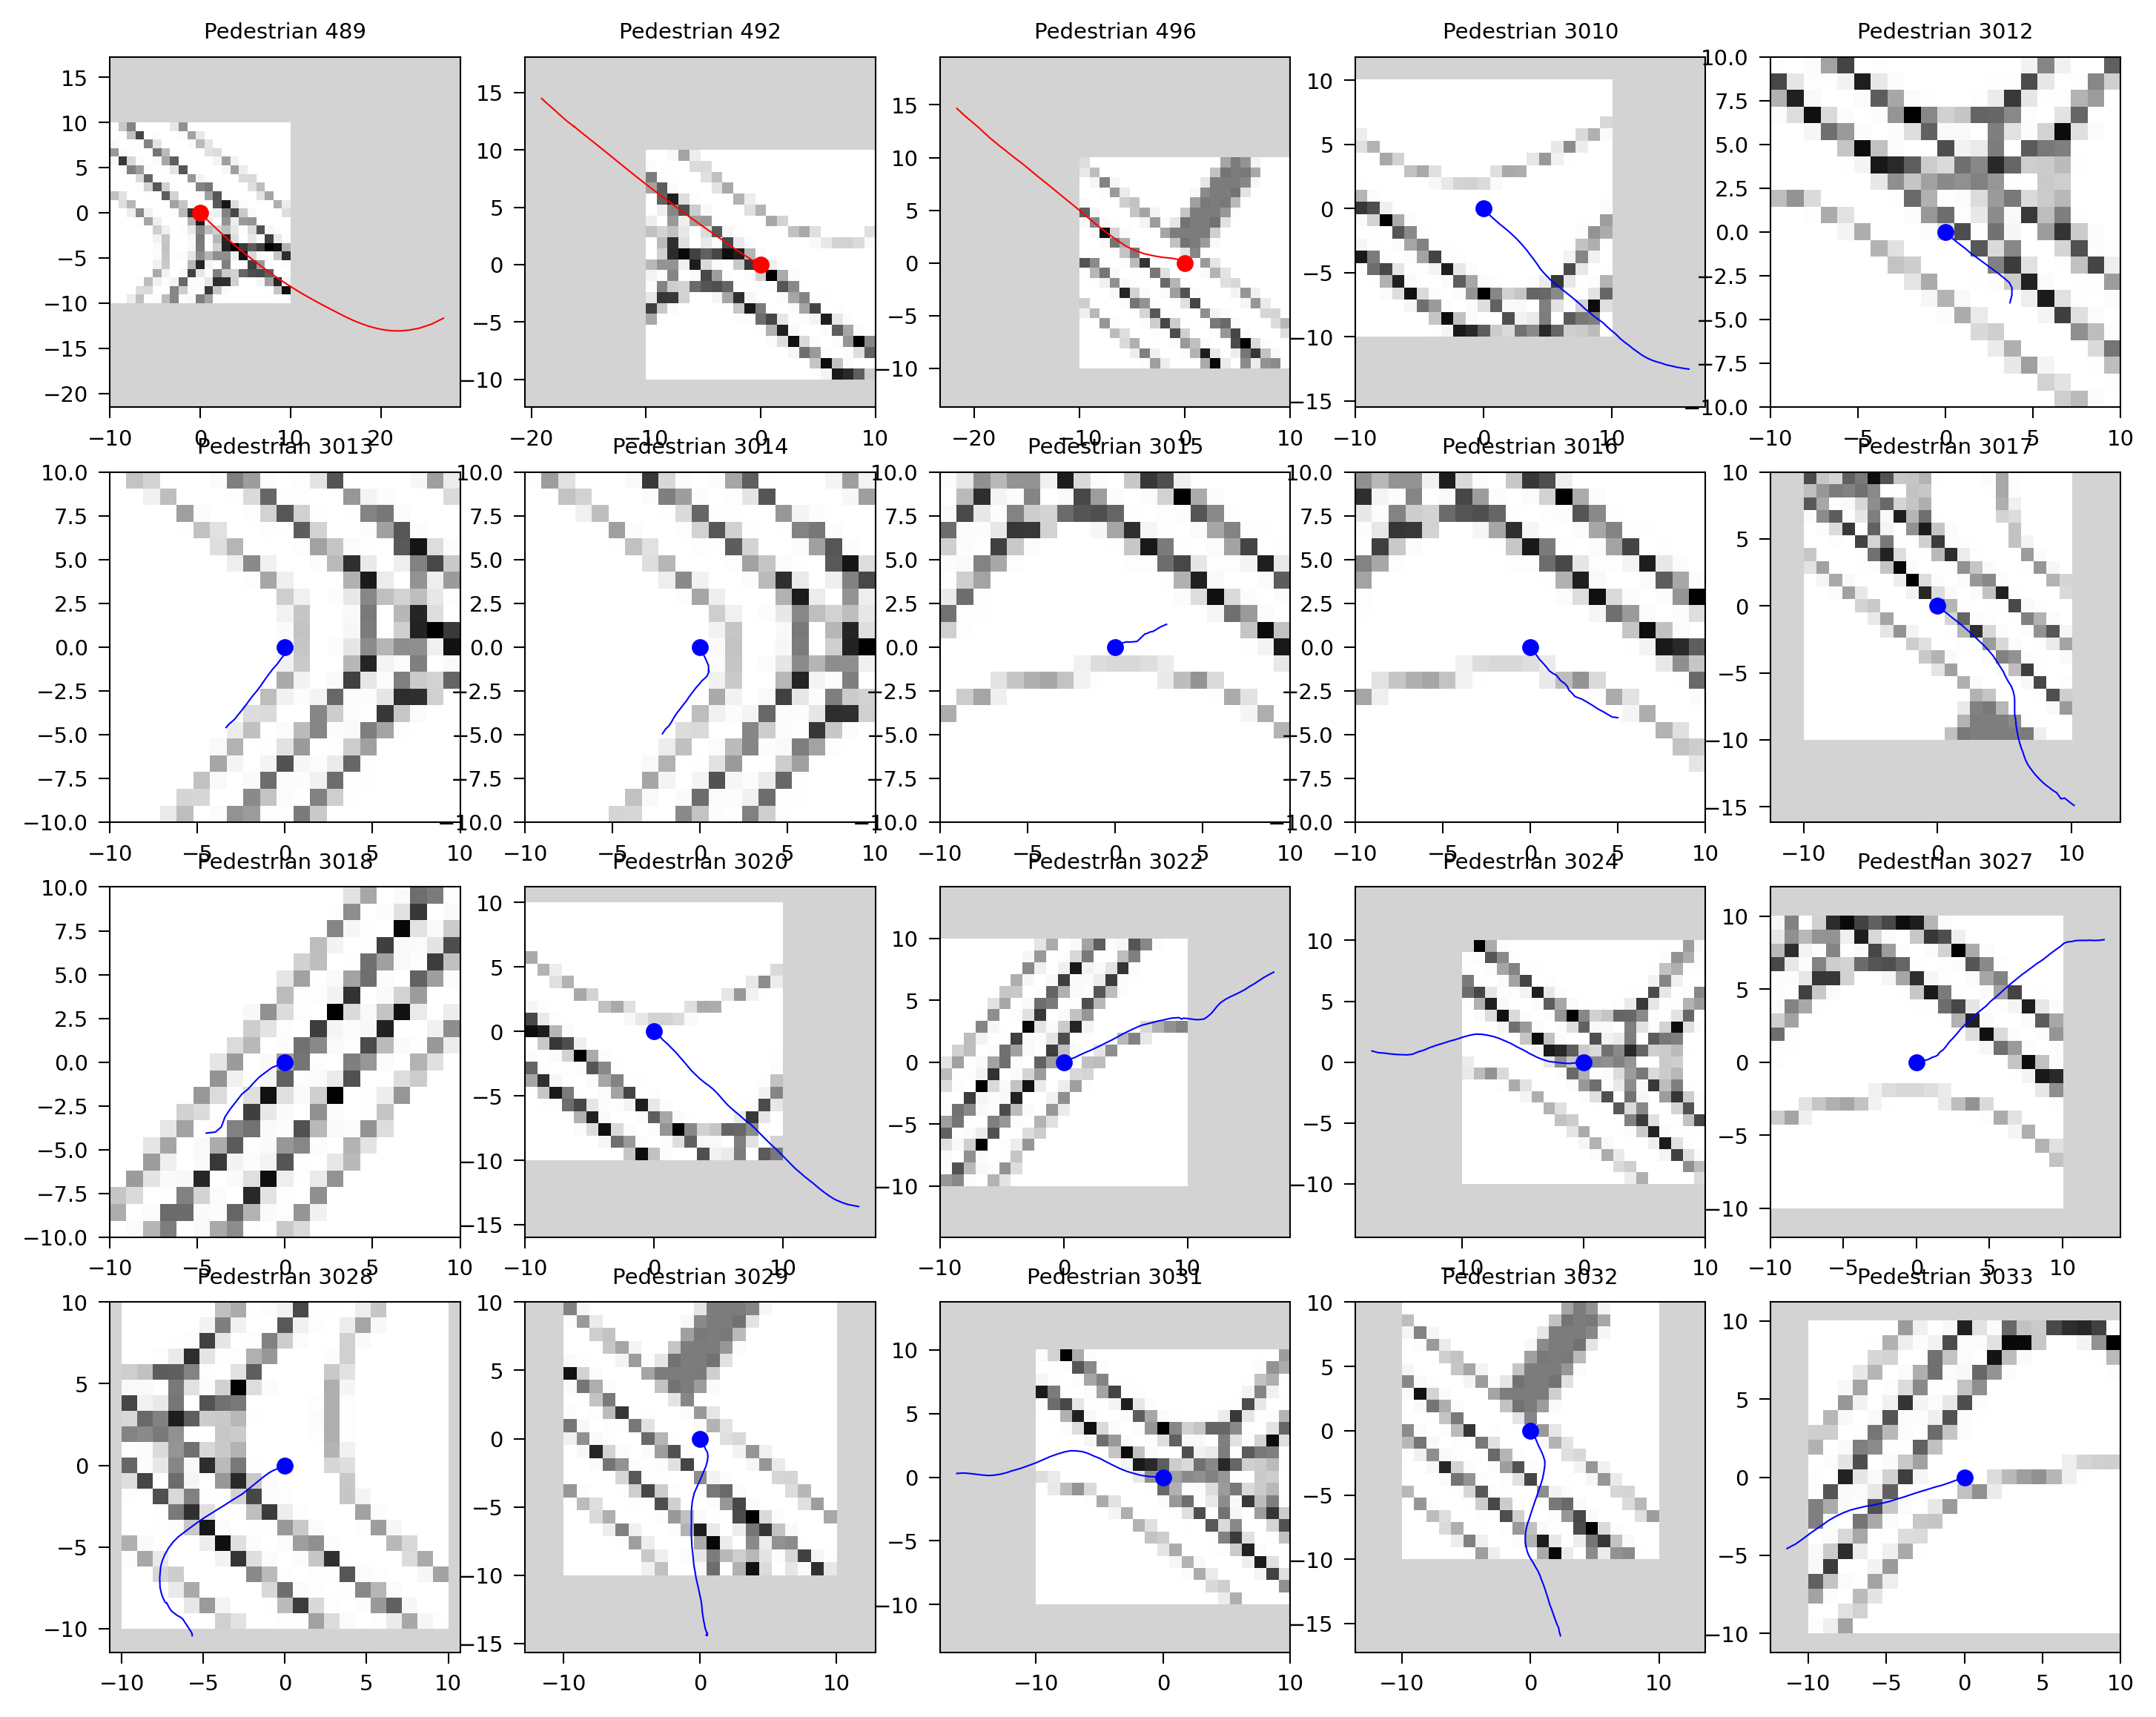

In [8]:
import torch
from src.utils.plot import get_fig
from src.utils.extract_patches import extract_patches_numpy, extract_patches_torch

map = torch.from_numpy(map_data.map)
pos = torch.from_numpy(df_data[['x', 'y']].values) # (N, 2)
idx = pos[..., 0].sub(map_data.xmin).div(map_data.xmax-map_data.xmin).mul(map.shape[0]).round().long().clamp(0, map.shape[0] - 1)  # (batch_size, #pedestrian)
jdx = pos[..., 1].sub(map_data.ymin).div(map_data.ymax-map_data.ymin).mul(map.shape[1]).round().long().clamp(0, map.shape[1] - 1)  # (batch_size, #pedestrian)
patches = extract_patches_torch(map, idx, jdx, r=10)

N = min(patches.shape[0], 20)
C = 5
R = np.ceil(N / C).astype(int)
fi, fig, axes = get_fig(R, C, AW=4, AH=4)

for i in range(N):
    ax = axes[i]
    ax.set_facecolor('lightgray')
    im = ax.imshow(patches[i].T, extent=[-10,10,-10,10], origin='lower', cmap='gray_r', interpolation='nearest', aspect='auto')
    ax.set_title(f'Pedestrian {df_data["id"].iloc[i]}')
    traj = dataset.df_data[dataset.df_data["id"]==df_data["id"].iloc[i]]
    color = 'blue' if traj["type"].iloc[0] == 'pedestrian' else 'red'
    ax.scatter(0, 0, c=color, s=20, label='Current Position')
    ax.plot(traj["x"] - df_data['x'].iloc[i], traj["y"] - df_data['y'].iloc[i], c=color, label='Trajectory')
    ax.axis('equal')

In [ ]:
r = 10
x = np.arange(-r, r+1)
y = np.arange(-r, r+1)
xy = np.stack(np.meshgrid(x, y, indexing='ij'), axis=-1)  # (2r+1, 2r+1, 2)
d = np.linalg.norm(xy, axis=-1, keepdims=True)  # (2r+1, 2r+1, 1)
n = -xy / d.clip(min=1e-6)
F_map = 3.0 * np.exp(-d / 0.6) * n  # (2r+1, 2r+1, 2)
map_force = (patches[:, :, :, np.newaxis] * F_map[np.newaxis, :, :, :]).sum(axis=(1,2))

In [93]:
dp = (pos[:, np.newaxis, :] - pos[np.newaxis, :, :])
dist = np.linalg.norm(dp, axis=-1, keepdims=True)
n_ij = dp / dist.clip(min=1e-6)
F_ped = 2.0 * np.exp(-dist / 0.3) * n_ij
ped_force = F_ped.sum(axis=1)

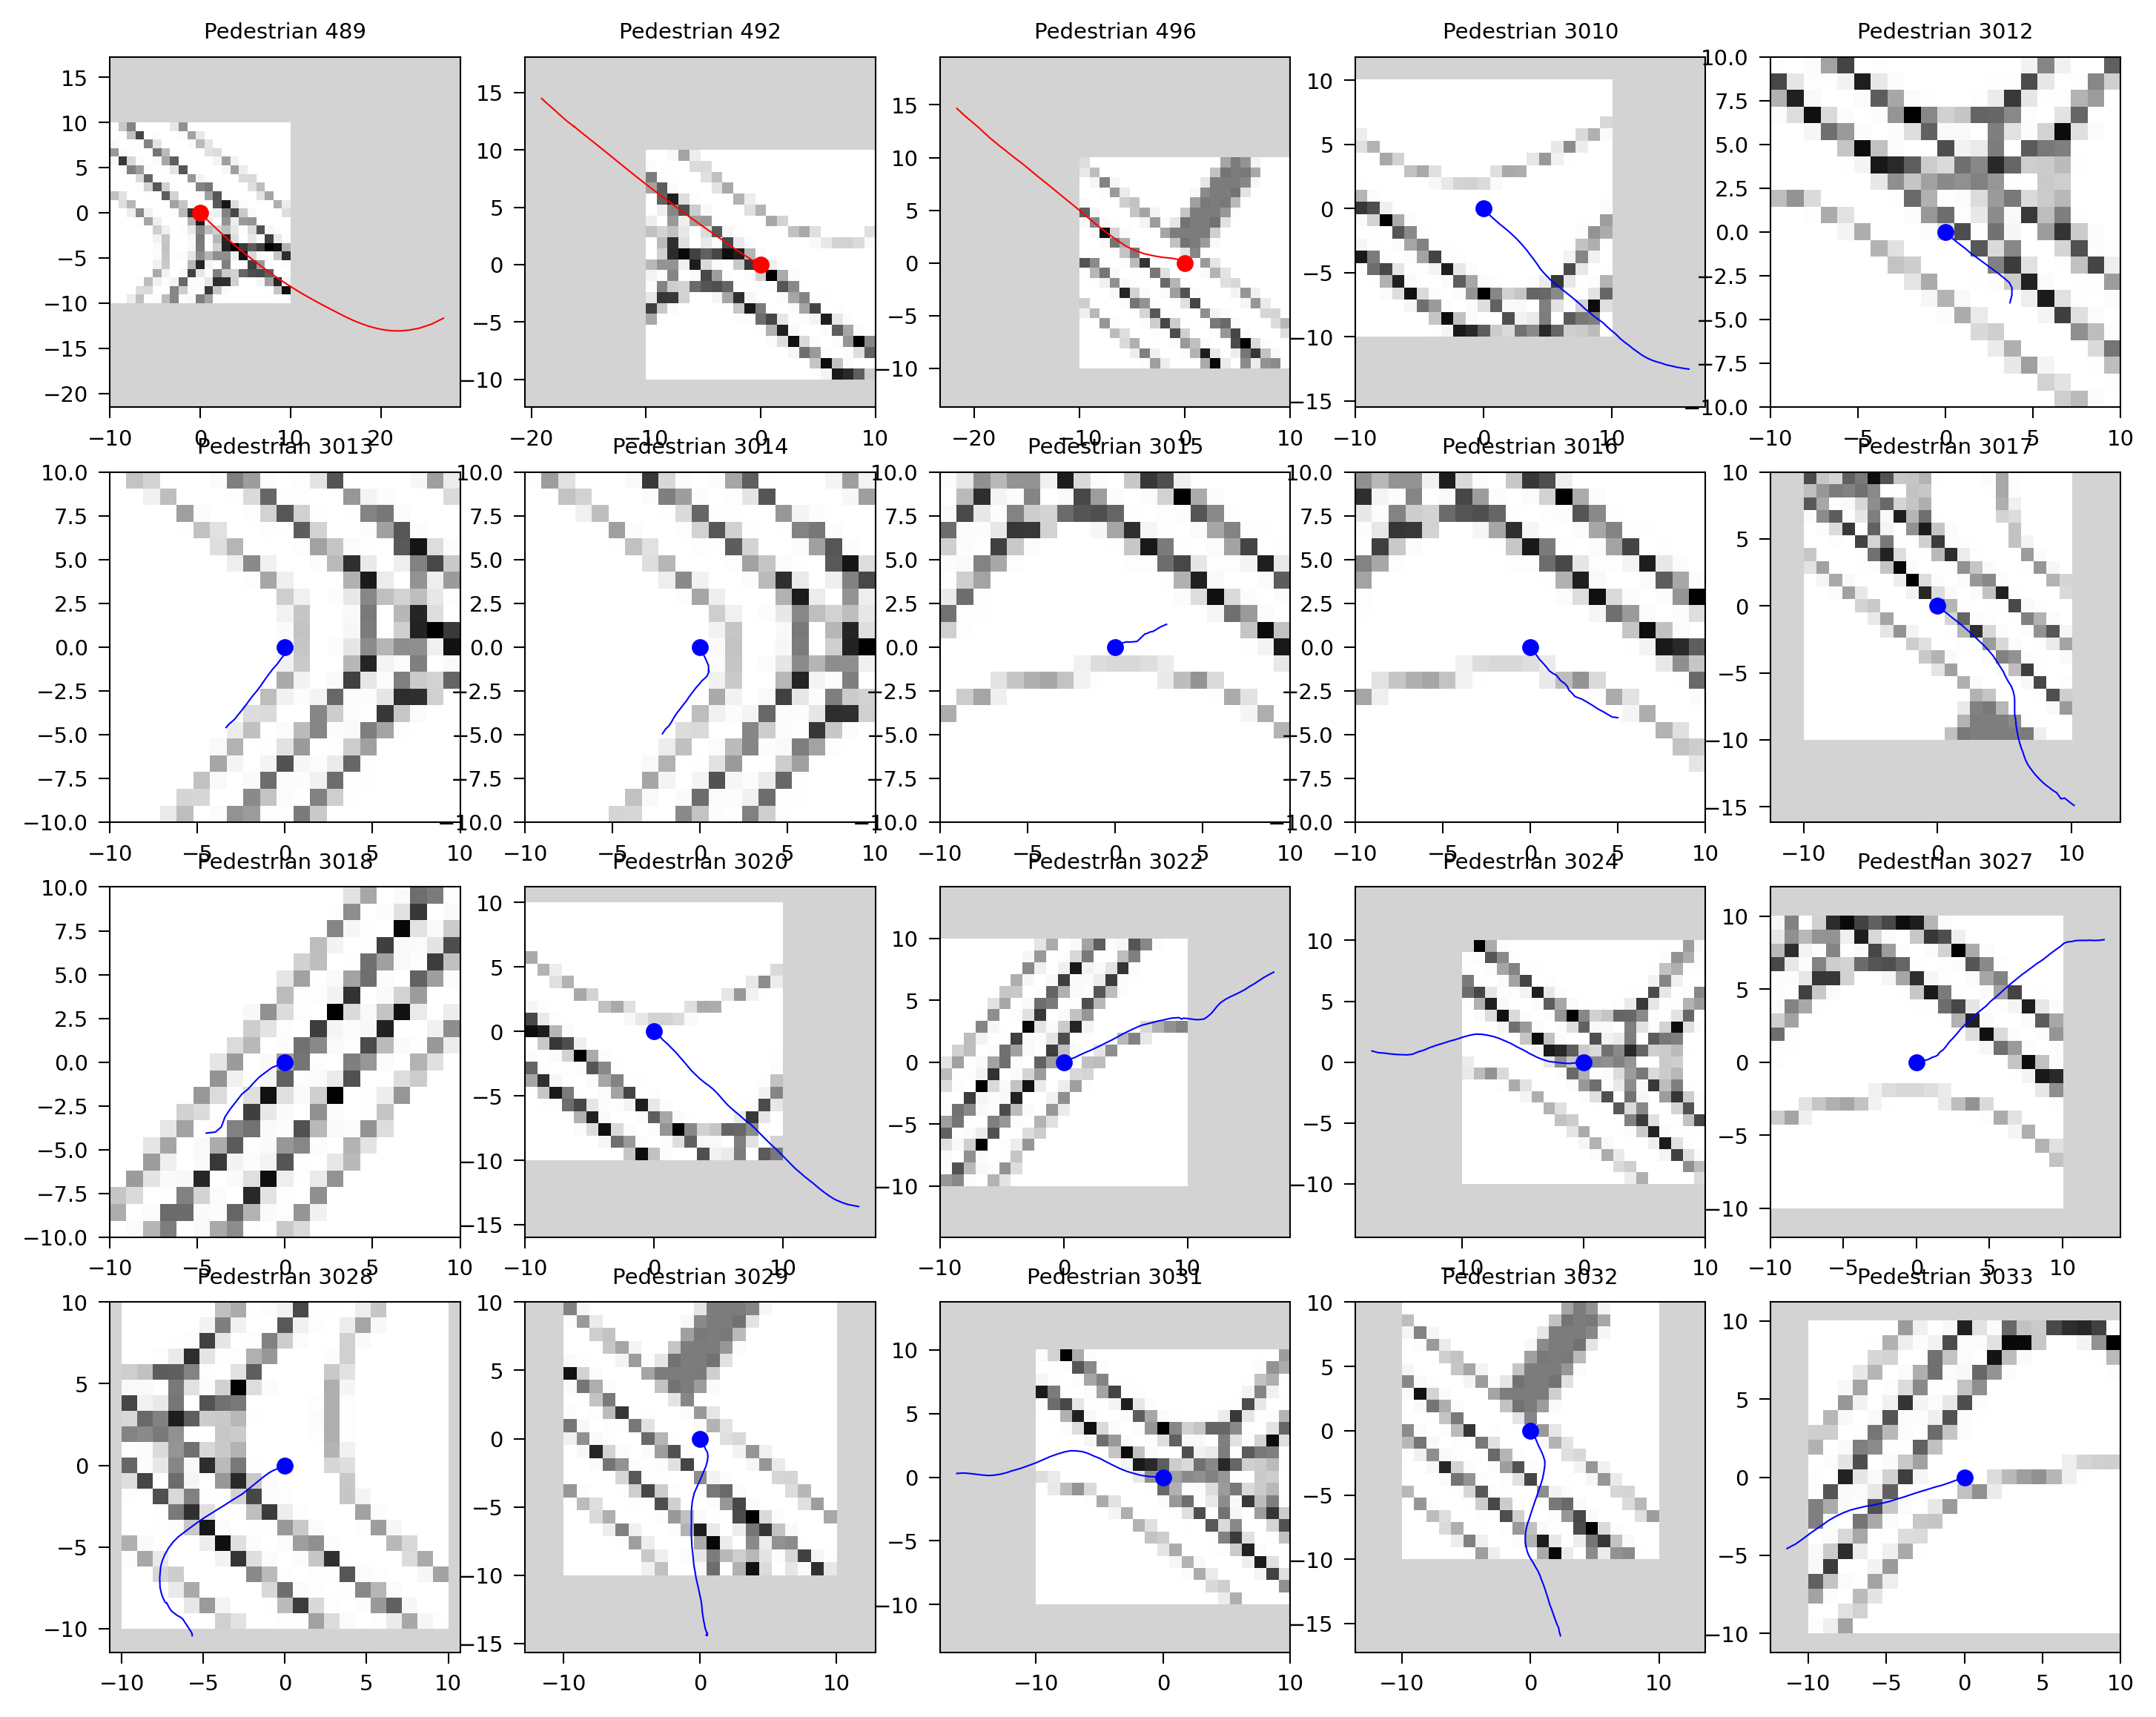

In [94]:
import numpy as np
from numpy.lib.stride_tricks import as_strided

def extract_patches(arr, idx, jdx, r=10):
    """
    参数:
    arr: (w, h) 输入的 2D np.ndarray
    idx, jdx: (l,) 中心的行、列坐标
    r: 半径 (默认10, 切片为 -10 到 +11, 窗口大小为 21x21)
    
    返回:
    (l, 2r+1, 2r+1) 的数组，越界部分填充 NaN
    """
    # 1. 数据类型检查：为了填充 NaN，数组必须是浮点型
    # 如果为了极致速度且确定原数据已是 float，可跳过此步
    if not np.issubdtype(arr.dtype, np.floating):
        arr = arr.astype(float)
    # 2. Padding (填充)
    # 在上下左右各填充 r 个 NaN
    # 原始 (0,0) 现在位于 padded 的 (r, r)
    padded = np.pad(arr, pad_width=r, mode='constant', constant_values=np.nan)
    # 3. 构建 Strided View (虚拟视图)
    # 我们希望 view[i, j] 对应的是以原始 (i,j) 为左上角的窗口吗？
    # 不，我们希望对应以原始 (i,j) 为 *中心* 的窗口。
    # 原始 (i,j) 对应 padded 中的 (i+r, j+r)。
    # 窗口范围是 [i+r-r : i+r+r+1] -> [i : i+2r+1]。
    # 所以，如果我们构建一个从 padded[0,0] 开始滑动的视图，
    # 那么 view[i, j] 恰好就是 padded[i:i+2r+1, j:j+2r+1]。
    # 创建视图 (瞬间完成，不复制数据)
    # 注意：这里的 shape 必须限制在 arr.shape 大小，否则 view 索引会越界
    # 但实际上我们只索引 idx, jdx，只要它们在合法范围内即可
    # 输出视图的形状：(原行数, 原列数, 窗口高, 窗口宽)
    s_row, s_col = padded.strides
    window_size = 2 * r + 1
    subs = as_strided(
        padded,
        shape=(arr.shape[0], arr.shape[1], window_size, window_size),
        strides=(s_row, s_col, s_row, s_col),
    )
    # 4. 利用花式索引提取结果
    # 这一步会发生内存复制，生成最终结果 (l, 21, 21)
    return subs[idx, jdx]

import torch
import torch.nn.functional as F

def extract_patches_torch(arr, idx, jdx, r=10):
    """
    参数:
    arr: (H, W) 输入的 2D Tensor
    idx, jdx: (..., l) 任意维度的中心坐标 LongTensor
    r: 半径 (默认10, 窗口大小为 21x21)
    
    返回:
    (..., l, 2r+1, 2r+1) 的 Tensor, 越界部分填充 NaN
    """
    # 1. 确保 arr 是浮点型 (为了填充 NaN)
    if not arr.is_floating_point():
        arr = arr.float()
        
    # 2. 预处理 Padding
    # F.pad 参数顺序: (Left, Right, Top, Bottom)
    # 原始 (0,0) 变成了 padded 中的 (r, r)
    padded = F.pad(arr, (r, r, r, r), mode='constant', value=float('nan'))
    
    # 获取 padded 后的尺寸边界
    p_h, p_w = padded.shape
    
    # 3. 构建局部窗口的相对偏移量
    # rows_offset: (2r+1, 1) -> 广播到列
    # cols_offset: (1, 2r+1) -> 广播到行
    rows_offset = torch.arange(-r, r + 1, device=arr.device).view(-1, 1)
    cols_offset = torch.arange(-r, r + 1, device=arr.device).view(1, -1)
    
    # 4. 计算绝对坐标网格 (Broadcasting Magic)
    # idx 维度假设为 (Batch, l) -> 扩展为 (Batch, l, 1, 1)
    # 最终 grid 维度为 (Batch, l, 2r+1, 2r+1)
    
    # 先把 idx/jdx 扩展到最后两维
    idx_expanded = idx.unsqueeze(-1).unsqueeze(-1)
    jdx_expanded = jdx.unsqueeze(-1).unsqueeze(-1)
    
    # 计算在 padded 坐标系中的位置 (原坐标 + r + 偏移)
    grid_rows = idx_expanded + r + rows_offset
    grid_cols = jdx_expanded + r + cols_offset
    
    # 5. 安全性处理：Clamp (钳位)
    # 防止极度越界导致 CUDA error。
    # 只要 clamp 在 padded 的范围内，取出的就是 padding 填充的 NaN，或者是有效数据。
    # 比如 idx=-1000, +r 后还是负数，clamp 到 0，取出的 padded[0,:] 是 NaN。符合预期。
    grid_rows = torch.clamp(grid_rows, 0, p_h - 1)
    grid_cols = torch.clamp(grid_cols, 0, p_w - 1)
    
    # 6. Gather / Indexing
    # 直接使用高级索引提取
    patches = padded[grid_rows, grid_cols]
    
    return patches

# --- 测试用例 ---
if __name__ == "__main__":
    # 1. 模拟地图 (100x100)
    w, h = 100, 100
    # 假设在 GPU 上 (如果有的话)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    map_data = torch.randn(w, h, device=device)

    # 2. 模拟任意维度的索引 (例如: Batch=2, Agents=3)
    # 形状: (2, 3)
    batch_idx = torch.tensor([[10, 50, -100], [99, 105, 50]], device=device) # 包含越界测试
    batch_jdx = torch.tensor([[10, 50, -100], [99, 105, 50]], device=device)

    # 3. 执行提取
    patches = extract_patches_torch(map_data, batch_idx, batch_jdx, r=10)

    print(f"Device: {device}")
    print(f"Idx shape: {batch_idx.shape}")   # (2, 3)
    print(f"Output shape: {patches.shape}")  # (2, 3, 21, 21)
    
    # 检查越界值 (应为 NaN)
    print(f"\nValue check for out-of-bound index (-100, -100):")
    print(f"Is NaN? {torch.isnan(patches[0, 2]).all()}") # True
    
    print(f"\nValue check for out-of-bound index (105, 105):")
    print(f"Is NaN? {torch.isnan(patches[1, 1]).all()}") # True

Device: cuda
Idx shape: torch.Size([2, 3])
Output shape: torch.Size([2, 3, 21, 21])

Value check for out-of-bound index (-100, -100):
Is NaN? True

Value check for out-of-bound index (105, 105):
Is NaN? False
